In [1]:
import numpy as np
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/home/susan/Desktop/AI/Lab3/bbc_news_dataset.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.0+ KB
None


In [3]:
X=df['Text']
y=df["Category"]
print(X.shape,y.shape)

(1490,) (1490,)


In [4]:
category_names=df['Category'].unique()
print(category_names)

['business' 'tech' 'politics' 'sport' 'entertainment']


In [5]:
value_counts=df["Category"].value_counts()
print(value_counts)

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


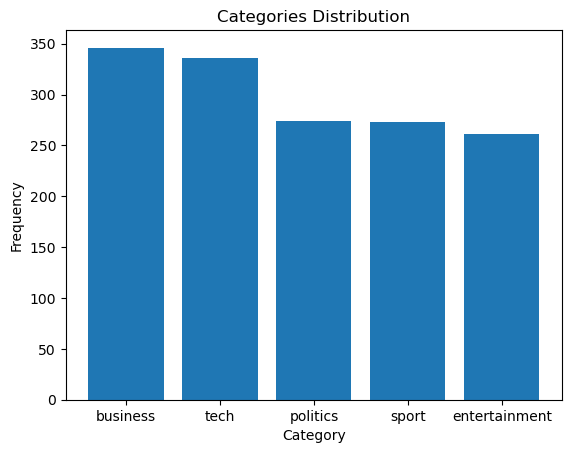

In [6]:
plt.bar(x=category_names, height=value_counts)
plt.title('Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

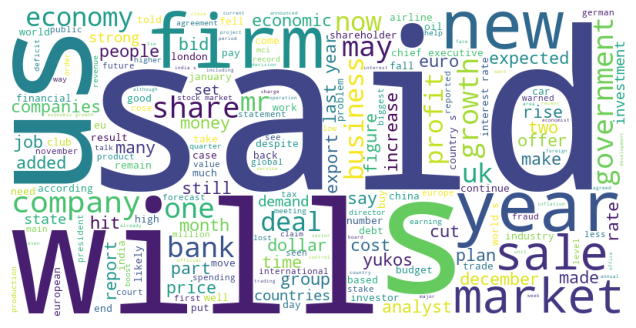

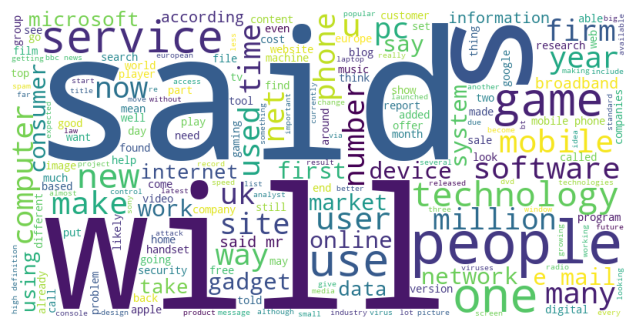

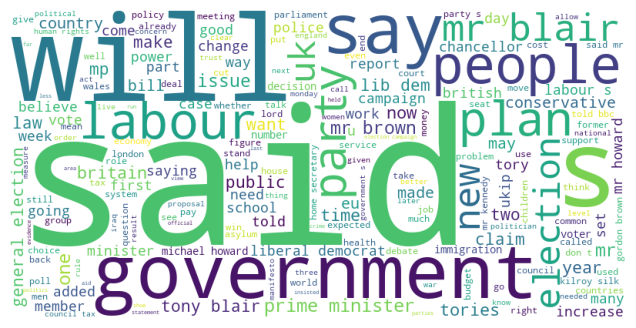

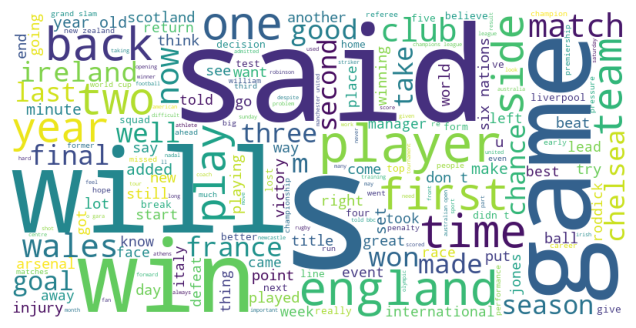

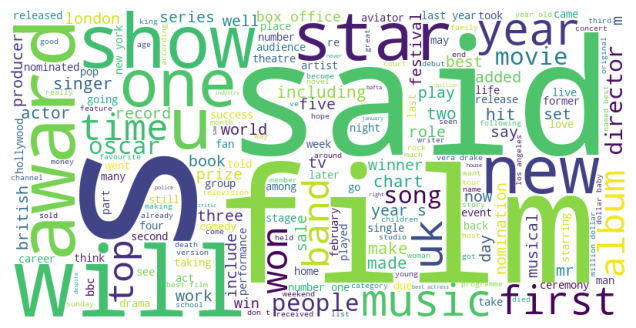

In [7]:
#create a wordcloud
for category in category_names:
    text = " ".join(df[df['Category']==category]['Text'].values)
    wc=WordCloud(width=800, height=400,background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
model = make_pipeline(
TfidfVectorizer(stop_words='english',max_features=2000),

MultinomialNB()
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.96      0.97      0.97        75
entertainment       1.00      0.98      0.99        46
     politics       0.95      0.95      0.95        56
        sport       1.00      1.00      1.00        63
         tech       0.97      0.97      0.97        58

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



In [33]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
model = make_pipeline(

TfidfVectorizer(stop_words='english',ngram_range=(1,2)),
MultinomialNB()
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.98      0.99        46
     politics       0.95      0.95      0.95        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.91      0.95        58

     accuracy                           0.96       298
    macro avg       0.97      0.96      0.96       298
 weighted avg       0.96      0.96      0.96       298



In [34]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
model = make_pipeline(

TfidfVectorizer(stop_words='english',min_df=2),
MultinomialNB()
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.95      0.97      0.96        75
entertainment       1.00      0.98      0.99        46
     politics       0.91      0.95      0.93        56
        sport       0.98      1.00      0.99        63
         tech       0.98      0.91      0.95        58

     accuracy                           0.96       298
    macro avg       0.97      0.96      0.96       298
 weighted avg       0.96      0.96      0.96       298



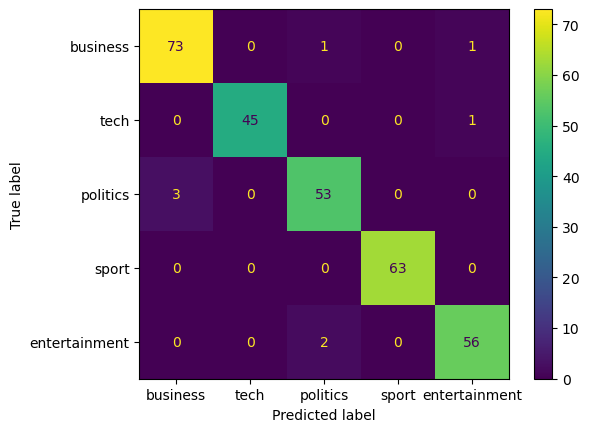

In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm,
display_labels=category_names).plot()

In [19]:
texts = ['Enter any news article text here.']
prediction = model.predict(texts)
print(prediction)

['tech']


In [20]:
import joblib

joblib.dump(model,'model.joblib')
print('Success')

Success


In [35]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
model = make_pipeline(

TfidfVectorizer(stop_words='english',ngram_range=(1,2)),
MultinomialNB()
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.98      0.99        46
     politics       0.95      0.95      0.95        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.91      0.95        58

     accuracy                           0.96       298
    macro avg       0.97      0.96      0.96       298
 weighted avg       0.96      0.96      0.96       298

